In [1]:
import numpy as np
import torch
from pathlib import Path
from objects.Functions import SpikeFunc
from objects.neuralnet import Network
from utilities.data_sampler import get_train_val_test
from utilities.trainer import base_model_train

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


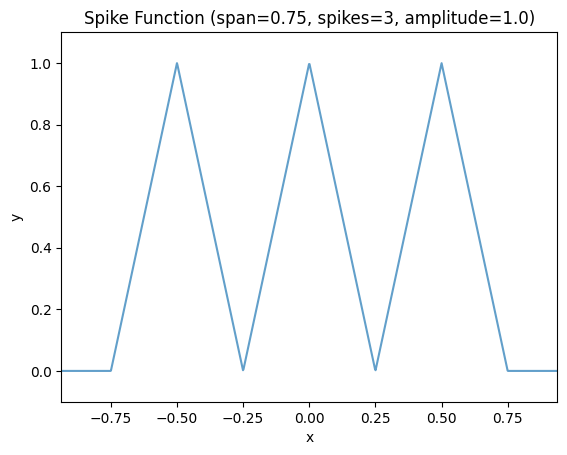

In [2]:
spike = SpikeFunc()
spike.plot()

In [3]:
train, val = get_train_val_test(spike, 42, 100000)


train size:	70000
val size:	30000


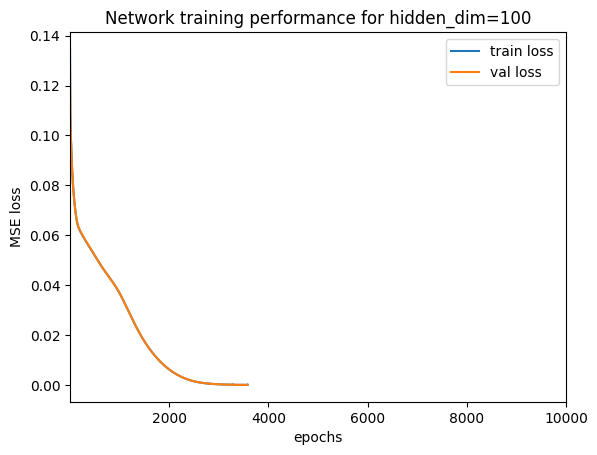

Early stopping at epoch 3582


In [7]:
# unpack the tuples
x_train, y_train = train
x_val, y_val = val

for hidden_size in [7, 50, 100]:
    Net = Network(hidden_size)
    base_model_train(Net, x_train, y_train, x_val, y_val, epochs=10000, lr=1e-3, device=device, patience=15)
    Net.save()

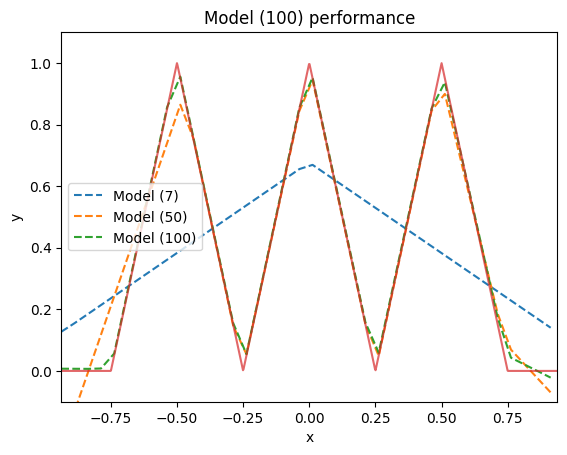

In [9]:
# Let's plot how well the models understands our function.
data = []
for hidden_size in [7, 50, 100]:
    Net = Network(hidden_size)
    Net.load()


    X = np.arange(-spike.span * 1.25, spike.span * 1.25, 0.05) 
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)
    Net = Net.to(device)
    Net.eval()
    Y = Net(X).to(device)
    X = X.detach().cpu().squeeze(1).numpy()
    Y = Y.detach().cpu().squeeze(1).numpy()

    data.append((X, Y, f"Model ({hidden_size})"))

    
    # spike.plot(output_data=[(X, Y, f"Model ({hidden_size})")], plot_title=f"Model ({Net.hidden_size}) performance", save_path=folder/f"base_model_perf.png")
        


folder = Path("results")
folder.mkdir(parents=True, exist_ok=True)
spike.plot(output_data=data, plot_title=f"Model ({Net.hidden_size}) performance", save_path=folder/f"base_model_perf.png")



In [ ]:
for hidden_size in [7, 50, 100]:
    Net = Network(hidden_size)
    Net.load()
    Net.plot_performance()